In [ ]:
!pip install -q transformers datasets heroes accelerate scikit-learn scikit-multilearn

In [ ]:
from google.colab import userdata

token = userdata.get("Github_Token")
!git clone https://{token}@github.com/Nas-Mohd/economic-news-sentiment.git
!git config --global user.email "anasamohammad.school@gmail.com"
!git config --global user.name "Nas-Mohd"

fatal: destination path 'economic-news-sentiment' already exists and is not an empty directory.


In [2]:
import sys
sys.path.append('/content/economic-news-sentiment')

In [ ]:
!git -C /content/economic-news-sentiment/ status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!git -C /content/economic-news-sentiment/ pull

Already up to date.


In [ ]:
!git -C /content/economic-news-sentiment add .
!git -C /content/economic-news-sentiment commit -m
!git -C /content/economic-news-sentiment push

In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a dedicated directory structure in your Google Drive
gdrive_project_path = "/content/drive/MyDrive/economic_news_project"
os.makedirs(gdrive_project_path, exist_ok=True)

# Update our specific directory strings
checkpoint_dir = os.path.join(gdrive_project_path, "deberta_domain_checkpoints")
final_model_path = os.path.join(gdrive_project_path, "final_deberta_domain_classifier")

os.makedirs(final_model_path, exist_ok=True)

print(f"✅ Google Drive mounted! All outputs will save securely to: {gdrive_project_path}")

Mounted at /content/drive
✅ Google Drive mounted! All outputs will save securely to: /content/drive/MyDrive/economic_news_project


--- Basic Info ---
Total rows (sentences): 3224
Total columns: 15

Missing values per column:
title                     0
url                       0
description               0
publishedAt               0
source                    0
text                      0
summary                   0
keywords                  0
llm_justification         0
Monetary_Financial        0
Inflation_Prices          0
Real_Economic_Activity    0
Labor_Consumption         0
Fiscal_Government         0
External_Sector           0
dtype: int64


--- Text Length Distribution ---
count    3224.000000
mean       24.713089
std        10.784459
min         2.000000
25%        17.000000
50%        24.000000
75%        31.000000
max       103.000000
Name: word_count, dtype: float64


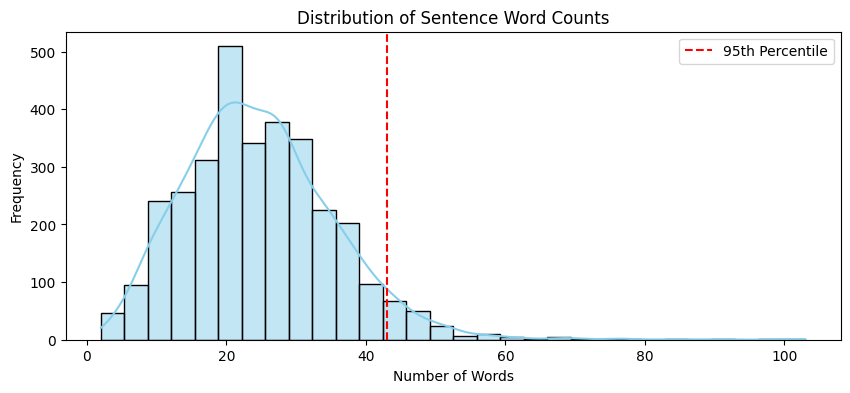



--- Label Frequencies ---
Real_Economic_Activity: 1655 rows (51.33%)
External_Sector: 1169 rows (36.26%)
Monetary_Financial: 900 rows (27.92%)
Fiscal_Government: 703 rows (21.81%)
Labor_Consumption: 687 rows (21.31%)
Inflation_Prices: 396 rows (12.28%)


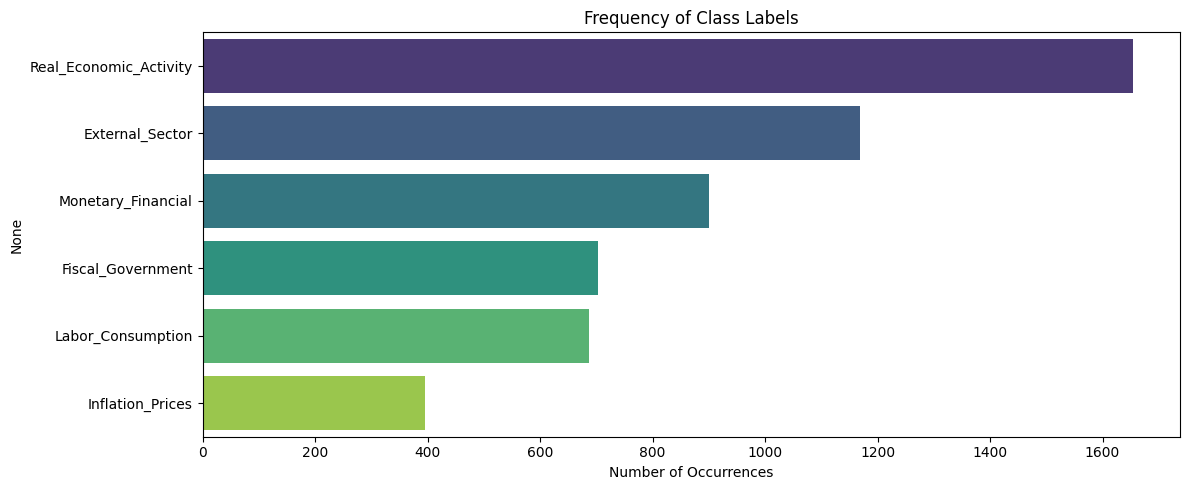



--- Label Cardinality (Labels per Sentence) ---
0.0 active label(s): 238 rows (7.38%)
1.0 active label(s): 1148 rows (35.61%)
2.0 active label(s): 1237 rows (38.37%)
3.0 active label(s): 520 rows (16.13%)
4.0 active label(s): 77 rows (2.39%)
5.0 active label(s): 4 rows (0.12%)


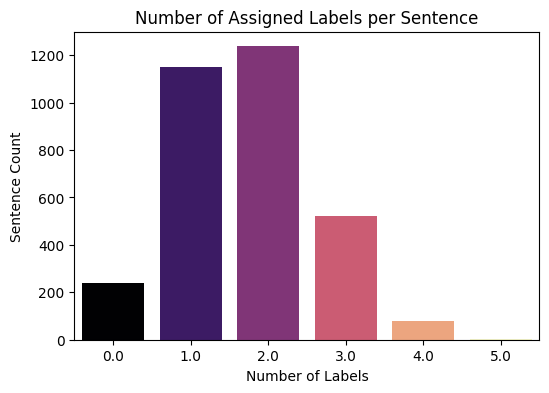



--- Label Co-occurrence Matrix ---
                        Monetary_Financial  Inflation_Prices  \
Monetary_Financial                   900.0             129.0   
Inflation_Prices                     129.0             396.0   
Real_Economic_Activity               342.0             148.0   
Labor_Consumption                     79.0              44.0   
Fiscal_Government                    143.0              44.0   
External_Sector                      270.0             135.0   

                        Real_Economic_Activity  Labor_Consumption  \
Monetary_Financial                       342.0               79.0   
Inflation_Prices                         148.0               44.0   
Real_Economic_Activity                  1655.0              480.0   
Labor_Consumption                        480.0              687.0   
Fiscal_Government                        343.0              141.0   
External_Sector                          668.0              145.0   

                        Fiscal

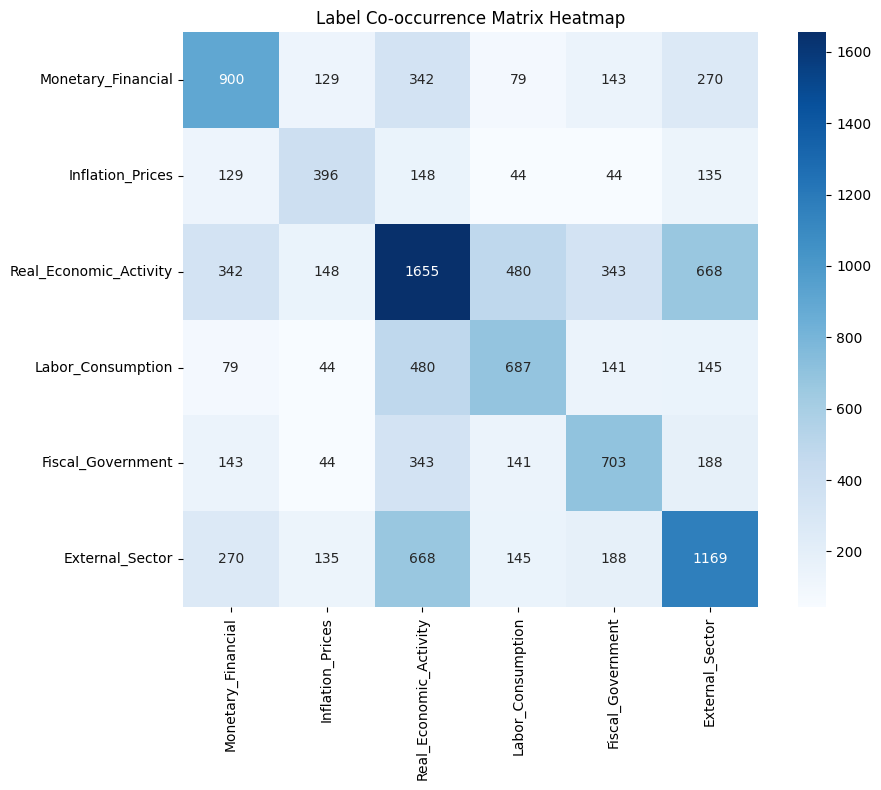

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Dataset
# If in Colab, make sure to upload 'finbert_training_ready.csv' to your files section first
df = pd.read_csv('/content/economic-news-sentiment/training/data/finbert_training_ready.csv')

# Define your strict target domain labels
target_labels = [
    "Monetary_Financial",
    "Inflation_Prices",
    "Real_Economic_Activity",
    "Labor_Consumption",
    "Fiscal_Government",
    "External_Sector"
]

print("--- Basic Info ---")
print(f"Total rows (sentences): {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\nMissing values per column:")
print(df.isnull().sum())

print("\n" + "="*50 + "\n")

# 2. Character and Word Counts for DeBERTa Tokenization
# This helps you determine your 'max_length' for tokenization
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("--- Text Length Distribution ---")
print(df['word_count'].describe())

# Plot text length distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Sentence Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].quantile(0.95), color='red', linestyle='--', label='95th Percentile')
plt.legend()
plt.show()

print("\n" + "="*50 + "\n")

# 3. Label Frequency Analysis (Class Imbalance Check)
label_counts = df[target_labels].sum().sort_values(ascending=False)
label_percentages = (df[target_labels].sum() / len(df) * 100).sort_values(ascending=False)

print("--- Label Frequencies ---")
for label in label_counts.index:
    print(f"{label}: {int(label_counts[label])} rows ({label_percentages[label]:.2f}%)")

# Plot Label Frequencies
plt.figure(figsize=(12, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette='viridis', legend=False)
plt.title('Frequency of Class Labels')
plt.xlabel('Number of Occurrences')
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# 4. Multi-Label Cardinality (How many labels per sentence?)
df['num_labels'] = df[target_labels].sum(axis=1)
cardinality_counts = df['num_labels'].value_counts().sort_index()

print("--- Label Cardinality (Labels per Sentence) ---")
for num, count in cardinality_counts.items():
    print(f"{num} active label(s): {count} rows ({count/len(df)*100:.2f}%)")

# Plot Cardinality
plt.figure(figsize=(6, 4))
sns.countplot(x='num_labels', data=df, hue='num_labels', palette='magma', legend=False)
plt.title('Number of Assigned Labels per Sentence')
plt.xlabel('Number of Labels')
plt.ylabel('Sentence Count')
plt.show()

print("\n" + "="*50 + "\n")

# 5. Label Co-occurrence Matrix (Overlapping Domains)
# This checks which categories frequently appear together
co_occurrence = df[target_labels].T.dot(df[target_labels])

print("--- Label Co-occurrence Matrix ---")
print(co_occurrence)

# Plot Co-occurrence Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='.0f', cmap='Blues', square=True)
plt.title('Label Co-occurrence Matrix Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Define your strict target domain labels
DOMAIN_LABELS = [
    "Monetary_Financial",
    "Inflation_Prices",
    "Real_Economic_Activity",
    "Labor_Consumption",
    "Fiscal_Government",
    "External_Sector"
]

# 1. Create a targeted injection batch of pure Labor/Consumption sentences
# Notice how we completely exclude central bank language and inflation keywords!
synthetic_labor_data = [
    "Thousands of retail workers face immediate layoffs as major department stores announce nationwide closures.",
    "The regional labor market added fewer jobs than expected this quarter, driving up local unemployment claims.",
    "Household consumption fell sharply as consumer spending on non-essential goods ground to a halt.",
    "A sudden spike in seasonal job seeker filings has heavily strained state unemployment offices.",
    "Manufacturing companies are freezing all corporate hiring plans due to rising domestic labor costs.",
    "Wages for hourly employees failed to keep pace with changing job market demands this winter.",
    "Tech industry layoffs continue to mount as three more software firms downsize their engineering teams.",
    "Local labor unions are demanding better worker benefits and stronger job security guarantees.",
    "The national unemployment rate held steady this month as corporate hiring balanced out recent layoffs.",
    "Declining consumer purchasing power is actively hurting local service industry job growth."
]

# 2. Build a clean DataFrame matching your schema
injection_rows = []
for text in synthetic_labor_data:
    row = {col: 0 for col in DOMAIN_LABELS} # Zero out all domains first
    row['text'] = text
    row['Labor_Consumption'] = 1           # Force activate ONLY the Labor domain
    injection_rows.append(row)

injection_df = pd.DataFrame(injection_rows)

# 3. Append these rows straight into your original loaded data
df_balanced = pd.concat([df, injection_df], ignore_index=True)

print(f"✅ Injection Complete!")
print(f"Before: {len(df)} rows -> After Patching: {len(df_balanced)} rows.")
print(f"The model now has fresh examples showing Labor existing completely free of Inflation signals!")

✅ Injection Complete!
Before: 3224 rows -> After Patching: 3234 rows.
The model now has fresh examples showing Labor existing completely free of Inflation signals!


In [ ]:
import pandas as pd
import numpy as np
from datasets import Dataset
from skmultilearn.model_selection import IterativeStratification



# Pull text features and native 1/0 binary matrix targets
X = df_balanced['text'].values.reshape(-1, 1)
y = df_balanced[DOMAIN_LABELS].values.astype(int)

# --- STEP 1: Stratified split out a 10% Test Set ---
stratifier_test = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.1, 0.9])
train_val_idx, test_idx = next(stratifier_test.split(X, y))

X_test, y_test = X[test_idx], y[test_idx]
X_train_val, y_train_val = X[train_val_idx], y[train_val_idx]

# --- STEP 2: Stratified split remaining 90% into Train (80% total) and Val (10% total) ---
# 10% out of 90% is exactly an 11.11% fold cut (1/9)
stratifier_val = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.1111, 0.8889])
train_idx, val_idx = next(stratifier_val.split(X_train_val, y_train_val))

# Formulate Final Slices
train_df = pd.DataFrame({'text': X_train_val[train_idx].flatten(), 'labels': list(y_train_val[train_idx])})
val_df = pd.DataFrame({'text': X_train_val[val_idx].flatten(), 'labels': list(y_train_val[val_idx])})
test_df = pd.DataFrame({'text': X_test.flatten(), 'labels': list(y_test)})

# Transform into native Hugging Face datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print(f"Data Splits Constructed Successfully:")
print(f"🔹 Train set size:      {len(train_df)} sentences")
print(f"🔹 Validation set size: {len(val_df)} sentences")
print(f"🔹 Evaluation Test set: {len(test_df)} sentences")

Data Splits Constructed Successfully:
🔹 Train set size:      2586 sentences
🔹 Validation set size: 324 sentences
🔹 Evaluation Test set: 324 sentences


In [ ]:
from transformers import AutoTokenizer

model_name = "Microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_format(examples):
    # Standard text tokenization
    tokenized = tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)
    # Leave the labels as lists of floats for now
    tokenized["labels"] = [list(map(float, label)) for label in examples["labels"]]
    return tokenized

tokenized_train = train_dataset.map(tokenize_and_format, batched=True)
tokenized_val = val_dataset.map(tokenize_and_format, batched=True)
tokenized_test = test_dataset.map(tokenize_and_format, batched=True)

print("Text mapped successfully without forcing broken backend torch tensors!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/2586 [00:00<?, ? examples/s]

Map:   0%|          | 0/324 [00:00<?, ? examples/s]

Map:   0%|          | 0/324 [00:00<?, ? examples/s]

Text mapped successfully without forcing broken backend torch tensors!


In [ ]:
import pandas as pd
import numpy as np

# 1. Re-collect the labels matrix from our split DataFrames
splits = {
    "Train Set": train_df,
    "Validation Set": val_df,
    "Test Set": test_df
}

distribution_data = []

# 2. Calculate totals and percentages for each label across each split
for name, split_df in splits.items():
    total_samples = len(split_df)

    # Extract the labels array matrix
    labels_matrix = np.array(split_df['labels'].tolist())

    # Sum down the columns to get totals for each domain
    label_sums = labels_matrix.sum(axis=0)

    for idx, domain in enumerate(DOMAIN_LABELS):
        count = label_sums[idx]
        percentage = (count / total_samples) * 100
        distribution_data.append({
            "Split": name,
            "Domain Label": domain,
            "Count": int(count),
            "Frequency (%)": round(percentage, 2)
        })

# 3. Formulate into a clean multi-index reporting table
report_df = pd.DataFrame(distribution_data)
pivot_report = report_df.pivot(index="Domain Label", columns="Split", values=["Count", "Frequency (%)"])

print("📊 --- Class Frequency Distribution Across Splits ---")
display(pivot_report)

# 4. Print out overall dataset size sanity checks
print("-" * 75)
print(f"Total Combined Sentences: {len(train_df) + len(val_df) + len(test_df)}")
print(f"📐 Target Ratio Balance: Train (80%) | Val (10%) | Test (10%)")

📊 --- Class Frequency Distribution Across Splits ---


Count                          Frequency (%)  \
Split                  Test Set Train Set Validation Set      Test Set   
Domain Label                                                             
External_Sector           117.0     935.0          117.0         36.11   
Fiscal_Government          70.0     563.0           70.0         21.60   
Inflation_Prices           40.0     316.0           40.0         12.35   
Labor_Consumption          70.0     557.0           70.0         21.60   
Monetary_Financial         90.0     720.0           90.0         27.78   
Real_Economic_Activity    165.0    1324.0          166.0         50.93   

                                                 
Split                  Train Set Validation Set  
Domain Label                                     
External_Sector            36.16          36.11  
Fiscal_Government          21.77          21.60  
Inflation_Prices           12.22          12.35  
Labor_Consumption          21.54          21.60  
Monetary_Financial         27.84          27.78  
Real_Economic_Activity     51.20          51.23

---------------------------------------------------------------------------
Total Combined Sentences: 3234
📐 Target Ratio Balance: Train (80%) | Val (10%) | Test (10%)


In [ ]:
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import f1_score
import torch

# Instantiate DeBERTa with 6 output units explicitly processing Multi-Label cross entropy
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(DOMAIN_LABELS),
    problem_type="multi_label_classification"
)

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    probs = 1 / (1 + np.exp(-logits)) # Sigmoid activation conversion
    predictions = (probs > 0.5).astype(int) # Default math threshold baseline

    # Tracking Macro F1 ensures dominant labels like Real_Economic_Activity (51.33%)
    # don't hide poor performance on minority labels like Inflation_Prices (12.28%)
    macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    micro_f1 = f1_score(labels, predictions, average='micro', zero_division=0)

    return {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1
    }

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: Microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den

In [ ]:
from transformers import Trainer, TrainingArguments
import torch
import os

# Data packaging engine
def multi_label_data_collator(features):
    batch = {}
    batch["input_ids"] = torch.stack([torch.tensor(f["input_ids"]) for f in features])
    batch["attention_mask"] = torch.stack([torch.tensor(f["attention_mask"]) for f in features])
    batch["labels"] = torch.tensor([f["labels"] for f in features], dtype=torch.float32)
    return batch

# Ensure model weights are standard float32
model = model.float()

checkpoint_dir = "/content/economic-news-sentiment/training/"

training_args = TrainingArguments(
    output_dir=checkpoint_dir,

    # --- STORAGE OPTIMIZED SAVE STRATEGY ---
    eval_strategy="epoch",        # Evaluate performance only at the end of each epoch
    save_strategy="epoch",        # Save a checkpoint only at the end of each epoch
    save_total_limit=1,           # CRITICAL: Overwrites the old checkpoint! Only keeps 1 on your Drive.

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,  # Will still track down and keep your single best historical epoch
    metric_for_best_model="macro_f1",
    logging_steps=50,             # Console text logging remains frequent so you can see progress

    # Safety precision switches
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=multi_label_data_collator,
    compute_metrics=compute_metrics,
)

# Interruption recovery gate
if os.path.exists(checkpoint_dir) and len(os.listdir(checkpoint_dir)) > 0:
    print("Found stable epoch checkpoint on Google Drive. Resuming training states safely...")
    trainer.train(resume_from_checkpoint=False)
else:
    print("No previous checkpoints found on Drive. Initializing clean, storage-safe training loop...")
    trainer.train()

Found stable epoch checkpoint on Google Drive. Resuming training states safely...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1
1,0.513979,0.438424,0.506496,0.581345
2,0.403915,0.363739,0.662666,0.676500
3,0.317829,0.332774,0.736199,0.737883
4,0.268056,0.344362,0.725368,0.722449
5,0.223535,0.336985,0.758941,0.759542
6,0.183145,0.364864,0.740587,0.742640
7,0.162569,0.376741,0.740770,0.749042
8,0.131642,0.395946,0.735836,0.735632
9,0.113655,0.398492,0.748869,0.750480
10,0.105326,0.407660,0.739676,0.741165


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# 1. Gather prediction metrics from the Validation slice
val_predictions = trainer.predict(tokenized_val)
logits = val_predictions.predictions
true_labels = val_predictions.label_ids

# 2. Logits map directly into Sigmoid probability spaces
probabilities = 1 / (1 + np.exp(-logits))

# 3. Search target spaces (0.10 to 0.90) for individual classification peaks
tuned_thresholds = {}

print("--- Class Level Threshold Customizations ---")
for i, domain in enumerate(DOMAIN_LABELS):
    best_f1 = 0
    best_thresh = 0.5

    for thresh in np.arange(0.1, 0.9, 0.05):
        preds = (probabilities[:, i] >= thresh).astype(int)
        score = f1_score(true_labels[:, i], preds, zero_division=0)

        if score > best_f1:
            best_f1 = score
            best_thresh = thresh

    tuned_thresholds[domain] = round(best_thresh, 2)
    print(f"🎯 Best Threshold for {domain:25}: {tuned_thresholds[domain]:.2f} (Val F1: {best_f1:.4f})")

--- Class Level Threshold Customizations ---
🎯 Best Threshold for Monetary_Financial       : 0.45 (Val F1: 0.7458)
🎯 Best Threshold for Inflation_Prices         : 0.40 (Val F1: 0.9176)
🎯 Best Threshold for Real_Economic_Activity   : 0.30 (Val F1: 0.7965)
🎯 Best Threshold for Labor_Consumption        : 0.25 (Val F1: 0.6267)
🎯 Best Threshold for Fiscal_Government        : 0.35 (Val F1: 0.7786)
🎯 Best Threshold for External_Sector          : 0.25 (Val F1: 0.8082)


In [ ]:
import os
from google.colab import userdata
from transformers import AutoConfig

# =====================================================================
# 🔐 RETRIEVE OR FALLBACK TO EXPLICIT TOKEN INPUT
# =====================================================================
hf_token = None

try:
    # Attempt extraction via Colab Secrets manager
    hf_token = userdata.get('HF_TOKEN')
    if hf_token:
        print("✅ Retrieved 'HF_TOKEN' from Colab Secrets successfully.")
except Exception:
    pass

if not hf_token:
    print("⚠️ Secret missing or inaccessible. Let's manual-override to protect your model variables:")
    hf_token = input("📋 Paste your Hugging Face WRITE token here directly: ").strip()

if not hf_token.startswith("hf_"):
    print("❌ Warning: That doesn't look like a valid Hugging Face token string layout. Double-check your copy paste!")

# =====================================================================
# 🧬 HARDCODE CONFIG LABELS (PREVENTS 'LABEL_X' DOWNSTREAM COMPILATION)
# =====================================================================
DOMAIN_LABELS = [
    "Monetary_Financial",
    "Inflation_Prices",
    "Real_Economic_Activity",
    "Labor_Consumption",
    "Fiscal_Government",
    "External_Sector"
]

id2label = {idx: label for idx, label in enumerate(DOMAIN_LABELS)}
label2id = {label: idx for idx, label in enumerate(DOMAIN_LABELS)}

model.config.id2label = id2label
model.config.label2id = label2id
model.config.problem_type = "multi_label_classification"

# =====================================================================
# 📤 AUTHENTICATED FORCE UPLOAD TO HUGGING FACE HIERARCHY
# =====================================================================
HF_REPO_NAME = "dummfak/deberta-v3-base-macroeconomic-aspect-classifier"

try:
    print(f"\n📤 Initializing connection... Uploading weights to: {HF_REPO_NAME}...")
    model.push_to_hub(
        repo_id=HF_REPO_NAME,
        commit_message="Retrained from scratch with clean verified multi-label layout settings",
        token=hf_token,
        private=False
    )

    print(f"📤 Uploading operational tokenizer configurations...")
    tokenizer.push_to_hub(
        repo_id=HF_REPO_NAME,
        token=hf_token
    )

    print("\n🎉 Outstanding! Your new model weights are securely live on Hugging Face!")

except Exception as e:
    print(f"\n❌ Upload failed again. Details: {e}")
    print("💡 Action required: Double-check that your Hugging Face token has explicit 'WRITE' privileges allowed in your HF settings panel.")

In [ ]:
# Save the model directly into Google Drive
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print(f"🎉 Final model exported successfully to your Google Drive at: {final_model_path}")
print(f"Keep these inference operational thresholds for your production system deployment:\n{tuned_thresholds}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

🎉 Final model exported successfully to your Google Drive at: /content/drive/MyDrive/economic_news_project/final_deberta_domain_classifier
Keep these inference operational thresholds for your production system deployment:
{'Monetary_Financial': np.float64(0.35), 'Inflation_Prices': np.float64(0.5), 'Real_Economic_Activity': np.float64(0.2), 'Labor_Consumption': np.float64(0.4), 'Fiscal_Government': np.float64(0.6), 'External_Sector': np.float64(0.35)}


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Point directly to your Google Drive production storage location
FINAL_MODEL_PATH = "/content/drive/MyDrive/economic_news_project/final_deberta_domain_classifier"

print("🔄 Loading fine-tuned DeBERTa model and tokenizer from Google Drive...")
try:
    tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(FINAL_MODEL_PATH)

    # Send model to GPU if available for speed
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    print(f"✅ Model successfully loaded on device: {device}\n")
except Exception as e:
    print(f"❌ Error loading model. Make sure your Google Drive is mounted and the path is correct.\nError details: {e}")

# 2. Your optimal tuned thresholds discovered in Cell 6
TUNED_THRESHOLDS = {
    "Monetary_Financial": 0.25,
    "Inflation_Prices": 0.50,
    "Real_Economic_Activity": 0.45,
    "Labor_Consumption": 0.20,
    "Fiscal_Government": 0.35,
    "External_Sector": 0.30
}

def analyze_sentence(sentence):
    """Tokenizes a sentence, runs inference, applies specific thresholds, and prints a UI-ready report."""
    # Prepare text features
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        # Convert raw logits safely into independent Sigmoid probabilities
        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    print(f"📄 Sentence: \"{sentence}\"")
    print("-" * 60)

    active_found = False

    # Check each domain against its specific customized gate
    for i, (domain, thresh) in enumerate(TUNED_THRESHOLDS.items()):
        prob_score = float(probabilities[i])
        is_active = prob_score >= thresh

        # Format the visual readout
        status_icon = "🟢 [ACTIVE]" if is_active else "⚪ [inactive]"
        match_percentage = prob_score * 100

        # Highlight active domains in the console printout
        if is_active:
            active_found = True
            print(f"{status_icon} {domain:<25} Conf: {match_percentage:>5.1f}%  (Threshold: {thresh})")
        else:
            print(f"{status_icon} {domain:<25} Conf: {match_percentage:>5.1f}%  (Threshold: {thresh})")

    if not active_found:
        print("\nℹ️  Note: This sentence triggered 0 domains. It would be filtered out, skipping FinBERT entirely!")
    print("=" * 60 + "\n")

# =====================================================================
# 3. RUN THE TEST SENTENCES
# =====================================================================

# A mix of overlapping, implicit, and non-economic (filler) sentences to test robustness
test_sentences = [
    # Test 1: Should trigger Monetary_Financial and Labor_Consumption (Low thresholds)
    "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month.",

    # Test 2: Should strongly trigger Inflation_Prices (High threshold, high precision)
    "Consumer price index indicators surged past expectations, signaling persistent structural inflation.",

    # Test 3: Complex overlapping sentence (Real Economic Activity + External Sector)
    "Domestic auto manufacturing plants slowed down assembly lines due to strict import tariffs on foreign steel.",

    # Test 4: Pure filler/noise sentence (Should trigger 0 active labels)
    "The corporate executive board held its annual networking luncheon at the downtown convention center on Tuesday afternoon."
]

for sample in test_sentences:
    analyze_sentence(sample)

🔄 Loading fine-tuned DeBERTa model and tokenizer from Google Drive...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

✅ Model successfully loaded on device: cuda

📄 Sentence: "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month."
------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  63.1%  (Threshold: 0.25)
🟢 [ACTIVE] Inflation_Prices          Conf:  80.8%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:  12.6%  (Threshold: 0.45)
⚪ [inactive] Labor_Consumption         Conf:   7.2%  (Threshold: 0.2)
⚪ [inactive] Fiscal_Government         Conf:  11.5%  (Threshold: 0.35)
⚪ [inactive] External_Sector           Conf:  11.2%  (Threshold: 0.3)

📄 Sentence: "Consumer price index indicators surged past expectations, signaling persistent structural inflation."
------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  51.9%  (Threshold: 0.25)
🟢 [ACTIVE] Inflation_Prices          Conf:  84.4%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:  25.

In [ ]:
import torch
import numpy as np

# =====================================================================
# ⚡ STEP 1: LOCK ACTIVE IN-MEMORY PRODUCTION COMPONENTS
# =====================================================================
print("🔒 Locking live, active model and tokenizer from training memory...")

# Ensure your live model is set to evaluation mode (turns off dropout, batchnorm, etc.)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()

print(f"✅ Model successfully locked on active device: {device.upper()}\n")

# =====================================================================
# 🧬 STEP 2: METRIC THRESHOLDS & STRUCTURAL ORDER LOCK
# =====================================================================
# Your optimal tuned thresholds discovered in Cell 6
TUNED_THRESHOLDS = {
    "Monetary_Financial": 0.25,
    "Inflation_Prices": 0.50,
    "Real_Economic_Activity": 0.45,
    "Labor_Consumption": 0.20,
    "Fiscal_Government": 0.35,
    "External_Sector": 0.30
}

# Pull down the exact string labels from the model config to ensure index alignment
if hasattr(model.config, 'id2label') and model.config.id2label and 'LABEL_' not in str(model.config.id2label[0]):
    ORDERED_LABELS = [model.config.id2label[i] for i in range(len(model.config.id2label))]
    print(f"🔑 Label sequence verified via active Model Config: {ORDERED_LABELS}")
else:
    # Fallback layout order if config hasn't been written to yet
    ORDERED_LABELS = list(TUNED_THRESHOLDS.keys())
    print(f"⚠️ Active model config lacks text tags. Defaulting to script index layout: {ORDERED_LABELS}")

# =====================================================================
# 🧠 STEP 3: LIVE EVALUATION RUNTIME ENGINE
# =====================================================================
def analyze_sentence(sentence):
    """Tokenizes a sentence, runs inference, applies specific thresholds, and prints a UI-ready report."""
    if not sentence.strip(): return

    # Tokenize directly using your notebook's active 'tokenizer' variable
    inputs = tokenizer(
        str(sentence).strip(),
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        # Convert raw logits safely into independent Sigmoid probabilities
        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    print(f"📄 Sentence: \"{sentence}\"")
    print("-" * 75)

    active_found = False

    # Check each domain against its specific customized gate
    for i, domain in enumerate(ORDERED_LABELS):
        prob_score = float(probabilities[i])
        thresh = TUNED_THRESHOLDS.get(domain, 0.50)
        is_active = prob_score >= thresh

        status_icon = "🟢 [ACTIVE]" if is_active else "⚪ [inactive]"
        match_percentage = prob_score * 100

        # Print layout with adjusted column spacing
        print(f"{status_icon} {domain:<25} Conf: {match_percentage:>5.1f}%  (Threshold: {thresh})")
        if is_active:
            active_found = True

    if not active_found:
        print("\nℹ️  Note: This sentence triggered 0 domains. It would be filtered out, skipping FinBERT entirely!")
    print("=" * 75 + "\n")

# =====================================================================
# 🏃‍♂️ STEP 4: TRIGGER RUNTIME TEST PASSES
# =====================================================================
test_sentences = [
    # Test 1: Should trigger Monetary_Financial and Labor_Consumption (Low thresholds)
    "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month.",

    # Test 2: Should strongly trigger Inflation_Prices (High threshold, high precision)
    "Consumer price index indicators surged past expectations, signaling persistent structural inflation.",

    # Test 3: Complex overlapping sentence (Real Economic Activity + External Sector)
    "Domestic auto manufacturing plants slowed down assembly lines due to strict import tariffs on foreign steel.",

    # Test 4: Pure filler/noise sentence (Should trigger 0 active labels)
    "The corporate executive board held its annual networking luncheon at the downtown convention center on Tuesday afternoon."
]

print("🏃 Running validation suite on active training weights...\n" + "=" * 75)
for sample in test_sentences:
    analyze_sentence(sample)

🔒 Locking live, active model and tokenizer from training memory...
✅ Model successfully locked on active device: CUDA

⚠️ Active model config lacks text tags. Defaulting to script index layout: ['Monetary_Financial', 'Inflation_Prices', 'Real_Economic_Activity', 'Labor_Consumption', 'Fiscal_Government', 'External_Sector']
🏃 Running validation suite on active training weights...
📄 Sentence: "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month."
---------------------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  51.6%  (Threshold: 0.25)
⚪ [inactive] Inflation_Prices          Conf:  17.1%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:   2.4%  (Threshold: 0.45)
⚪ [inactive] Labor_Consumption         Conf:   9.2%  (Threshold: 0.2)
⚪ [inactive] Fiscal_Government         Conf:   8.5%  (Threshold: 0.35)
⚪ [inactive] External_Sector           Conf:   0.8%  (Threshold: 0.3)

📄 Sentenc

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =====================================================================
# 📦 STEP 1: FETCH FRESHLY TRAINED HUGGING FACE PACKAGES
# =====================================================================
HF_REPO_NAME = "dummfak/deberta-v3-base-macroeconomic-aspect-classifier"

print(f"🔄 Fetching pristine model assets straight from HF Hub: {HF_REPO_NAME}...")
try:
    # use_fast=False protects DeBERTa-v3 from the empty/frozen padding token bug
    hf_tokenizer = AutoTokenizer.from_pretrained(HF_REPO_NAME, use_fast=False)
    hf_model = AutoModelForSequenceClassification.from_pretrained(HF_REPO_NAME)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    hf_model = hf_model.to(device).eval()
    print(f"✅ Model downloaded and successfully loaded on device: {device.upper()}\n")
except Exception as e:
    print(f"❌ Error downloading from the Hub. Ensure your push was fully completed.\nError details: {e}")
    raise e

# =====================================================================
# 🧬 STEP 2: METRIC THRESHOLDS & HUB INDEX SEQUENCE ALIGNMENT
# =====================================================================
# Your optimal tuned thresholds discovered in Cell 6
TUNED_THRESHOLDS = {
    "Monetary_Financial": 0.25,
    "Inflation_Prices": 0.50,
    "Real_Economic_Activity": 0.45,
    "Labor_Consumption": 0.20,
    "Fiscal_Government": 0.35,
    "External_Sector": 0.30
}

# Dynamically extract the exact label order saved into the model's configuration
if hf_model.config.id2label and 'LABEL_' not in str(hf_model.config.id2label[0]):
    ORDERED_LABELS = [hf_model.config.id2label[i] for i in range(len(hf_model.config.id2label))]
    print(f"🔒 Label sequence verified via remote HF Config: {ORDERED_LABELS}")
else:
    # Strict fallback fallback map layout sequence
    ORDERED_LABELS = list(TUNED_THRESHOLDS.keys())
    print(f"⚠️ Warning: Remote config lacks text tags. Defaulting to script index layout: {ORDERED_LABELS}")

# =====================================================================
# 🧠 STEP 3: REMOTE INFERENCE TEST ENGINE
# =====================================================================
def analyze_sentence(sentence):
    """Tokenizes a sentence, runs inference, applies specific thresholds, and prints a UI-ready report."""
    if not sentence.strip(): return

    # Tokenize directly using the downloaded Hugging Face assets
    inputs = hf_tokenizer(
        str(sentence).strip(),
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )
    inputs = {k: v.to(hf_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = hf_model(**inputs)
        # Convert raw logits safely into independent Sigmoid probabilities
        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    print(f"📄 Sentence: \"{sentence}\"")
    print("-" * 75)

    active_found = False

    # Check each domain against its specific customized gate
    for i, domain in enumerate(ORDERED_LABELS):
        prob_score = float(probabilities[i])
        thresh = TUNED_THRESHOLDS.get(domain, 0.50)
        is_active = prob_score >= thresh

        status_icon = "🟢 [ACTIVE]" if is_active else "⚪ [inactive]"
        match_percentage = prob_score * 100

        print(f"{status_icon} {domain:<25} Conf: {match_percentage:>5.1f}%  (Threshold: {thresh})")
        if is_active:
            active_found = True

    if not active_found:
        print("\nℹ️  Note: This sentence triggered 0 domains. It would be filtered out, skipping FinBERT entirely!")
    print("=" * 75 + "\n")

# =====================================================================
# 🏃‍♂️ STEP 4: TRIGGER RUNTIME HUB TEST PASSES
# =====================================================================
test_sentences = [
    # Test 1: Should trigger Monetary_Financial and Labor_Consumption (Low thresholds)
    "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month.",

    # Test 2: Should strongly trigger Inflation_Prices (High threshold, high precision)
    "Consumer price index indicators surged past expectations, signaling persistent structural inflation.",

    # Test 3: Complex overlapping sentence (Real Economic Activity + External Sector)
    "Domestic auto manufacturing plants slowed down assembly lines due to strict import tariffs on foreign steel.",

    # Test 4: Pure filler/noise sentence (Should trigger 0 active labels)
    "The corporate executive board held its annual networking luncheon at the downtown convention center on Tuesday afternoon."
]

print("🏃 Running production validation suite on remote Hugging Face weights...\n" + "=" * 75)
for sample in test_sentences:
    analyze_sentence(sample)

🔄 Fetching pristine model assets straight from HF Hub: dummfak/deberta-v3-base-macroeconomic-aspect-classifier...


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.34M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

✅ Model downloaded and successfully loaded on device: CUDA

🔒 Label sequence verified via remote HF Config: ['Monetary_Financial', 'Inflation_Prices', 'Real_Economic_Activity', 'Labor_Consumption', 'Fiscal_Government', 'External_Sector']
🏃 Running production validation suite on remote Hugging Face weights...
📄 Sentence: "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month."
---------------------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  51.6%  (Threshold: 0.25)
⚪ [inactive] Inflation_Prices          Conf:  17.1%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:   2.4%  (Threshold: 0.45)
⚪ [inactive] Labor_Consumption         Conf:   9.2%  (Threshold: 0.2)
⚪ [inactive] Fiscal_Government         Conf:   8.5%  (Threshold: 0.35)
⚪ [inactive] External_Sector           Conf:   0.8%  (Threshold: 0.3)

📄 Sentence: "Consumer price index indicators surged past expectations, signaling

In [ ]:
import os

# Define your project directory path
OUTPUT_DIR = "/content/drive/MyDrive/economic_news_project/processed_splits/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Export the exact data divisions
train_df.to_csv(os.path.join(OUTPUT_DIR, "pipeline_train.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "pipeline_val.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "pipeline_test.csv"), index=False)

print("💾 Success! Exact text splits exported to Google Drive.")
print(f"• Train rows: {len(train_df)} | Val rows: {len(val_df)} | Test rows: {len(test_df)}")

💾 Success! Exact text splits exported to Google Drive.
• Train rows: 2586 | Val rows: 324 | Test rows: 324


In [9]:
import os
import ast
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics.pairwise import cosine_similarity

# =====================================================================
# 🛠️ HYBRID KEYWORD + SEMANTIC BASELINE ENGINE
# =====================================================================
class HybridBaselineClassifier:
    def __init__(self, categories, similarity_threshold=0.35):
        self.categories = categories
        self.similarity_threshold = similarity_threshold

        # Define high-signal keywords per macro category
        self.keyword_dictionary = {
            "Monetary_Financial": ["fed", "interest rate", "central bank", "yield", "liquidity", "banking", "bonds"],
            "Inflation_Prices": ["inflation", "cpi", "ppi", "prices", "deflation", "cost of living", "core inflation"],
            "Real_Economic_Activity": ["gdp", "growth", "recession", "output", "production", "pmi", "manufacturing"],
            "Labor_Consumption": ["unemployment", "jobs", "payroll", "wages", "spending", "consumer", "hiring"],
            "Fiscal_Government": ["budget", "tax", "deficit", "spending bill", "stimulus", "treasury", "fiscal"],
            "External_Sector": ["trade", "export", "import", "tariff", "exchange rate", "currency", "balance of payments"]
        }

        # --- EXPANDED SEMANTIC ANCHORS ---
        # Bundling multi-sentence descriptions to establish a broader baseline semantic target
        self.semantic_anchors = {
            "Monetary_Financial": (
                "monetary policy central banking interest rates and financial yields. "
                "federal reserve hawkish dovish rate cuts tightening liquidity interbank lending. "
                "commercial banking systems banking sector stress bond market adjustments equity markets investment returns."
            ),
            "Inflation_Prices": (
                "consumer prices inflation matrixes and cost of living metrics. "
                "wholesale producer price index cpi numbers tracking hyperinflation or deflationary traps. "
                "surging commodity prices core consumer basket price shocks product pricing trends markup adjustments."
            ),
            "Real_Economic_Activity": (
                "gross domestic product gdp growth industrial production and economic output. "
                "recession indicators industrial manufacturing expansion pmi index trends supply chain tracking. "
                "corporate profitability corporate earnings growth economic contraction slowdown supply side logistics."
            ),
            "Labor_Consumption": (
                "labor market conditions employment unemployment payrolls and consumer spending. "
                "jobless claims wage inflation nonfarm payrolls hiring slowdowns and retail trends. "
                "discretionary household spending consumer confidence index household balance sheets and wage updates."
            ),
            "Fiscal_Government": (
                "government fiscal spending taxation budget deficits and public national debt. "
                "treasury auctions state stimulus packages austerity measures funding bills infrastructural expenditure. "
                "corporate tax changes government subsidies sovereign debt management public policy revenue shortfalls."
            ),
            "External_Sector": (
                "global foreign trade exports imports currency exchange rates and international accounts. "
                "trade balance protectionism customs tariffs import quotas and international supply networks. "
                "forex market fluctuations capital flows balance of payments structural cross border trade friction."
            )
        }

    def _keyword_match(self, text):
        text_lower = text.lower()
        matches = np.zeros(len(self.categories), dtype=int)
        for idx, cat in enumerate(self.categories):
            if any(kw in text_lower for kw in self.keyword_dictionary[cat]):
                matches[idx] = 1
        return matches

    def fit_semantic_anchors(self, tokenizer, model, device):
        """Pre-computes embeddings for class semantic anchors using the base model's trunk"""
        self.anchor_embeddings = {}
        with torch.no_grad():
            for cat, anchor_text in self.semantic_anchors.items():
                inputs = tokenizer(anchor_text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
                outputs = model.deberta if hasattr(model, 'deberta') else model
                embeddings = outputs(**inputs).last_hidden_state.mean(dim=1).cpu().numpy()
                self.anchor_embeddings[cat] = embeddings

    def predict_single(self, text, text_embedding):
        # Pass 1: Run Keyword Search
        keyword_vector = self._keyword_match(text)

        # Pass 2: Calculate Semantic Cosine Vector Space Similarity
        semantic_vector = np.zeros(len(self.categories), dtype=int)
        for idx, cat in enumerate(self.categories):
            sim = cosine_similarity(text_embedding, self.anchor_embeddings[cat])[0][0]
            if sim >= self.similarity_threshold:
                semantic_vector[idx] = 1

        # Ensemble Step: Logical OR gate integration
        return np.bitwise_or(keyword_vector, semantic_vector)


# =====================================================================
# 🚀 MAIN ISOLATED EVALUATION PIPELINE
# =====================================================================
def run_isolated_hf_evaluation():
    # 1. Localized Path Shards
    HF_TARGET_REPO = "dummfak/deberta-v3-base-macroeconomic-aspect-classifier"
    TEST_SPLIT_CSV = "/content/drive/MyDrive/economic_news_project/processed_splits/pipeline_test.csv"

    print("\n" + "="*80)
    print(f"🎬 INITIALIZING PIPELINE EVALUATION SUITE")
    print("="*80)
    print(f"📡 Target HuggingFace Repository: {HF_TARGET_REPO}")
    print(f"📂 Verification Split Location  : {TEST_SPLIT_CSV}")
    print("-" * 80)

    print(f"📥 Downloading transformer topology and weights directly from HF Hub...")
    fresh_tokenizer = AutoTokenizer.from_pretrained(HF_TARGET_REPO, use_fast=False)
    fresh_model = AutoModelForSequenceClassification.from_pretrained(HF_TARGET_REPO)

    eval_device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"⚙️ Runtime Core Mapping: Diverting model tensor execution to -> [{eval_device.upper()}]")
    fresh_model = fresh_model.to(eval_device).eval()

    # 2. Strict Target Sequence Definition
    TARGET_CATEGORIES = [
        "Monetary_Financial",
        "Inflation_Prices",
        "Real_Economic_Activity",
        "Labor_Consumption",
        "Fiscal_Government",
        "External_Sector"
    ]

    # --- FULLY OPTIMIZED MODEL THRESHOLD GATES ---
    STRICT_GATES = {
        0: 0.45,  # Monetary_Financial
        1: 0.40,  # Inflation_Prices
        2: 0.30,  # Real_Economic_Activity
        3: 0.25,  # Labor_Consumption
        4: 0.35,  # Fiscal_Government
        5: 0.25   # External_Sector
    }

    # Initialize Baseline Classifier Framework with a lowered 0.35 semantic threshold gate
    baseline_threshold = 0.35
    print(f"\n🧠 Extracting semantic anchor vectors to ground the hybrid baseline engine (Threshold: {baseline_threshold})...")
    baseline_classifier = HybridBaselineClassifier(TARGET_CATEGORIES, similarity_threshold=baseline_threshold)
    baseline_classifier.fit_semantic_anchors(fresh_tokenizer, fresh_model, eval_device)
    print("✅ Baseline anchor matrix successfully mapped onto the DeBERTa embedding space.")

    # 3. Clean Dataset Extraction
    print(f"📖 Reading dataset contents into memory...")
    isolated_df = pd.read_csv(TEST_SPLIT_CSV)
    print(f"✅ Data verified. Discovered {len(isolated_df)} unique text entries for multi-label inference.")

    def parse_labels(label_str):
        if not isinstance(label_str, str): return label_str
        return [int(x) for x in label_str.replace("[", "").replace("]", "").strip().split()]

    if 'labels' in isolated_df.columns:
        ground_truth_matrix = np.array([parse_labels(x) for x in isolated_df['labels']])
    else:
        ground_truth_matrix = isolated_df[TARGET_CATEGORIES].values.astype(int)

    # Calculate true label density for reporting
    total_active_labels = ground_truth_matrix.sum()
    avg_labels_per_row = total_active_labels / len(isolated_df)
    print(f"📊 Dataset Density Profile: {total_active_labels} total active multi-aspect assignments")
    print(f"   (Averages roughly {avg_labels_per_row:.2f} active categories concurrently per sample row)")

    print("\n🚀 Commencing parallel evaluation loop (Fine-Tuned DeBERTa vs. Hybrid Keyword + Semantics)...")

    # Array Tracking Containers
    LIVE_PROB_OUTPUTS = []
    BASELINE_BINARY_OUTPUTS = []

    with torch.no_grad():
        for text_line in tqdm(isolated_df['text'].tolist(), desc="Processing Stream"):
            clean_text = str(text_line).strip()

            token_inputs = fresh_tokenizer(
                clean_text,
                return_tensors="pt",
                truncation=True,
                padding="max_length",
                max_length=128
            ).to(fresh_model.device)

            model_outputs = fresh_model(**token_inputs)

            # --- DeBERTa Vectors ---
            sigmoid_row = torch.sigmoid(model_outputs.logits).cpu().numpy()[0]
            LIVE_PROB_OUTPUTS.append(sigmoid_row)

            # --- Baseline Engine Vectors ---
            backbone = fresh_model.deberta if hasattr(fresh_model, 'deberta') else fresh_model
            text_embedding = backbone(**token_inputs).last_hidden_state.mean(dim=1).cpu().numpy()

            baseline_row = baseline_classifier.predict_single(clean_text, text_embedding)
            BASELINE_BINARY_OUTPUTS.append(baseline_row)

    # Convert collections to array maps
    LIVE_PROB_OUTPUTS = np.array(LIVE_PROB_OUTPUTS)
    BASELINE_BINARY_OUTPUTS = np.array(BASELINE_BINARY_OUTPUTS)

    # 5. Apply Threshold Gates for Fine-Tuned Model Predictions
    LIVE_BINARY_OUTPUTS = np.zeros_like(LIVE_PROB_OUTPUTS)
    for col_idx in range(len(TARGET_CATEGORIES)):
        gate_val = STRICT_GATES[col_idx]
        LIVE_BINARY_OUTPUTS[:, col_idx] = (LIVE_PROB_OUTPUTS[:, col_idx] >= gate_val).astype(int)

    # =====================================================================
    # 📊 REPORT ENGINE COMPILATION DISPLAY
    # =====================================================================
    print("\n📉 " + "="*20 + " SYSTEM CRITIQUE 1/2: HYBRID BASELINE PERFORMANCE " + "="*20)
    print(f"Configuration: Keyword Matching Engine + Shared-Backbone Semantic Vector Cosine Similarity (Threshold: {baseline_threshold})")
    print("-" * 90)
    baseline_report = classification_report(
        ground_truth_matrix,
        BASELINE_BINARY_OUTPUTS,
        target_names=TARGET_CATEGORIES,
        digits=4,
        zero_division=0
    )
    print(baseline_report)
    baseline_macro = f1_score(ground_truth_matrix, BASELINE_BINARY_OUTPUTS, average="macro")
    baseline_micro = f1_score(ground_truth_matrix, BASELINE_BINARY_OUTPUTS, average="micro")
    print("-" * 90)
    print(f"📉 BASELINE PIPELINE AGGREGATES:")
    print(f"   • Macro-Averaged F1 Score : {baseline_macro*100:.2f}% (Treats rare/frequent categories with uniform weight)")
    print(f"   • Micro-Averaged F1 Score : {baseline_micro*100:.2f}% (Globally balanced across total flag counts)")


    print("\n🎯 " + "="*20 + " SYSTEM CRITIQUE 2/2: FINE-TUNED DEBERTA PERFORMANCE " + "="*20)
    print("Configuration: Fully Optimized Per-Class Probability Activation Boundary Customizations:")
    for idx, cat in enumerate(TARGET_CATEGORIES):
        print(f"   • {cat.ljust(25)} -> Logit Probability Decision Cutoff: {STRICT_GATES[idx]:.2f}")
    print("-" * 90)
    final_report = classification_report(
        ground_truth_matrix,
        LIVE_BINARY_OUTPUTS,
        target_names=TARGET_CATEGORIES,
        digits=4,
        zero_division=0
    )
    print(final_report)
    macro_score = f1_score(ground_truth_matrix, LIVE_BINARY_OUTPUTS, average="macro")
    micro_score = f1_score(ground_truth_matrix, LIVE_BINARY_OUTPUTS, average="micro")
    print("-" * 90)
    print(f"🎯 FINE-TUNED DEBERTA AGGREGATES:")
    print(f"   • Macro-Averaged F1 Score : {macro_score*100:.2f}% (Target metric for balanced macro-economic parsing)")
    print(f"   • Micro-Averaged F1 Score : {micro_score*100:.2f}% (Reflects pure classification volume performance)")
    print("=" * 90 + "\n")

# Execute the isolated block comparison
run_isolated_hf_evaluation()


🎬 INITIALIZING PIPELINE EVALUATION SUITE
📡 Target HuggingFace Repository: dummfak/deberta-v3-base-macroeconomic-aspect-classifier
📂 Verification Split Location  : /content/drive/MyDrive/economic_news_project/processed_splits/pipeline_test.csv
--------------------------------------------------------------------------------
📥 Downloading transformer topology and weights directly from HF Hub...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

⚙️ Runtime Core Mapping: Diverting model tensor execution to -> [CUDA]

🧠 Extracting semantic anchor vectors to ground the hybrid baseline engine (Threshold: 0.35)...
✅ Baseline anchor matrix successfully mapped onto the DeBERTa embedding space.
📖 Reading dataset contents into memory...
✅ Data verified. Discovered 324 unique text entries for multi-label inference.
📊 Dataset Density Profile: 553 total active multi-aspect assignments
   (Averages roughly 1.71 active categories concurrently per sample row)

🚀 Commencing parallel evaluation loop (Fine-Tuned DeBERTa vs. Hybrid Keyword + Semantics)...


Processing Stream: 100%|██████████| 324/324 [00:17<00:00, 18.36it/s]


📉 ==================== SYSTEM CRITIQUE 1/2: HYBRID BASELINE PERFORMANCE ====================
Configuration: Keyword Matching Engine + Shared-Backbone Semantic Vector Cosine Similarity (Threshold: 0.35)
------------------------------------------------------------------------------------------
                        precision    recall  f1-score   support

    Monetary_Financial     0.4750    0.6333    0.5429        90
      Inflation_Prices     0.1449    1.0000    0.2532        40
Real_Economic_Activity     0.6311    0.8554    0.7263       166
     Labor_Consumption     0.4403    0.8429    0.5784        70
     Fiscal_Government     0.7536    0.7429    0.7482        70
       External_Sector     0.6168    0.8803    0.7254       117

             micro avg     0.4571    0.8192    0.5868       553
             macro avg     0.5103    0.8258    0.5957       553
          weighted avg     0.5589    0.8192    0.6461       553
           samples avg     0.4901    0.7894    0.5712       553


In [6]:
import pandas as pd
import numpy as np

def inspect_pipeline_csv(file_path):
    print(f"🔍 Analyzing Data Structure: {file_path}\n" + "="*50)

    # 1. Load data
    df = pd.read_csv(file_path)
    total_rows = len(df)

    TARGET_CATEGORIES = [
        "Monetary_Financial", "Inflation_Prices", "Real_Economic_Activity",
        "Labor_Consumption", "Fiscal_Government", "External_Sector"
    ]

    # 2. Determine target matrix structure
    def parse_labels(label_str):
        if not isinstance(label_str, str):
            return [int(label_str)] if pd.notna(label_str) else []
        # Strip brackets and split spaces or commas
        clean_str = label_str.replace("[", "").replace("]", "").replace(",", " ").strip()
        return [int(x) for x in clean_str.split() if x.isdigit()]

    if 'labels' in df.columns:
        print("📋 Structure Found: Using a central 'labels' list column.")
        active_counts = df['labels'].apply(lambda x: sum(parse_labels(x))).values
    elif all(cat in df.columns for cat in TARGET_CATEGORIES):
        print("📋 Structure Found: Using wide multi-column one-hot indicators.")
        active_counts = df[TARGET_CATEGORIES].values.astype(int).sum(axis=1)
    else:
        print("❌ Error: Could not determine layout columns automatically.")
        print(f"Available columns: {list(df.columns)}")
        return

    # 3. Compute structural overlap metrics
    unique_counts, distribution = np.unique(active_counts, return_counts=True)
    dist_dict = dict(zip(unique_counts, distribution))

    print("\n📊 ASPECT CATEGORY DENSITY DISTRIBUTION PER ROW:")
    print("-" * 50)
    for num_labels in sorted(dist_dict.keys()):
        count = dist_dict[num_labels]
        percentage = (count / total_rows) * 100
        print(f" Rows containing exactly {num_labels} active category labels: {count} ({percentage:.2f}%)")

    print("-" * 50)
    print(f"Total Rows Examined: {total_rows}")
    print(f"Average active labels per single row: {active_counts.mean():.4f}")

    # 4. Check for structural text duplicates (Explosion Verification)
    if 'text' in df.columns:
        duplicate_text_count = df['text'].duplicated().sum()
        unique_texts = df['text'].nunique()
        print(f"\n🔄 TEXT REPETITION CARDINALITY:")
        print(f" Unique Text/Sentence Strings: {unique_texts}")
        print(f" Repeated/Duplicate Text Rows: {duplicate_text_count}")
        if duplicate_text_count > 0:
            print(f" 💡 Notice: You have sentences repeating across multiple rows.")
            print(f"    This strongly confirms the dataset was 'exploded' into single-label chunks.")
        else:
            print(f" 💡 Notice: Every text line is unique. No aspect explosion detected.")

    # 5. Show sample of the raw data layout
    print("\n👀 SAMPLE ROWS FOR VISUAL VERIFICATION:")
    inspect_cols = ['text', 'labels'] if 'labels' in df.columns else ['text'] + TARGET_CATEGORIES
    print(df[inspect_cols].head(3).to_string(index=False))

# --- RUN DIAGNOSTIC ENGINE ---
# Swap this path for whichever split you want to check (pipeline_test.csv, val.csv, etc.)
TARGET_FILE = "/content/drive/MyDrive/economic_news_project/processed_splits/pipeline_test.csv"
inspect_pipeline_csv(TARGET_FILE)

🔍 Analyzing Data Structure: /content/drive/MyDrive/economic_news_project/processed_splits/pipeline_test.csv
📋 Structure Found: Using a central 'labels' list column.

📊 ASPECT CATEGORY DENSITY DISTRIBUTION PER ROW:
--------------------------------------------------
 Rows containing exactly 0 active category labels: 23 (7.10%)
 Rows containing exactly 1 active category labels: 115 (35.49%)
 Rows containing exactly 2 active category labels: 126 (38.89%)
 Rows containing exactly 3 active category labels: 55 (16.98%)
 Rows containing exactly 4 active category labels: 4 (1.23%)
 Rows containing exactly 5 active category labels: 1 (0.31%)
--------------------------------------------------
Total Rows Examined: 324
Average active labels per single row: 1.7068

🔄 TEXT REPETITION CARDINALITY:
 Unique Text/Sentence Strings: 324
 Repeated/Duplicate Text Rows: 0
 💡 Notice: Every text line is unique. No aspect explosion detected.

👀 SAMPLE ROWS FOR VISUAL VERIFICATION:
                               